# Bell States Using Qiskit

In [31]:
# =============================================================================
# Project: Bell States using Qiskit
# Author : Fahim Faisal
# Date   : June 2026

# Description:
# This project demonstrates the generation and measurement of the
# four Bell states using Qiskit. The circuits are executed on both
# AerSimulator and IBM Quantum hardware using Qiskit Runtime.
# =============================================================================

## Section 1: Imports

In [32]:
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

## Section 2: Environment Information

In [33]:
# Checking All the Versions
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.14.6
qiskit: 2.4.2
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.47.0


## Section 3: Bell - phi_plus State Construction

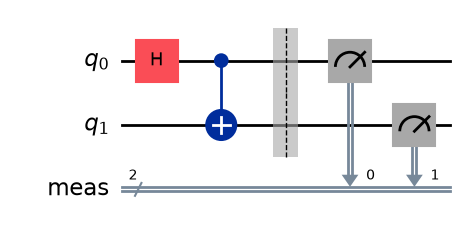

In [34]:
# ---------------------------------------------------------------------------
# Bell State Φ+ (Phi Plus)
#
# |Φ+⟩ = (|00⟩ + |11⟩)/√2
# Expected measurements:
#     00 ≈ 50%
#     11 ≈ 50%
# ---------------------------------------------------------------------------

# --- Build the Bell circuit (phi-plus) ---
phi_plus = QuantumCircuit(2)

# Create superposition on qubit 0
phi_plus.h(0)

# Entangle qubits
phi_plus.cx(0, 1)

# Measure all qubits
phi_plus.measure_all()  # creates a classical register named "meas"

# Draw the Circuit with Matplotlib
phi_plus.draw("mpl")

## Section 4: Execution Function

In [35]:
# Creating Function to Run the Circuit and Make Counts
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    
    # Transpile circuit for target backend
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    # Create Sampler primitive
    sampler = Sampler(mode=backend)

    # Submit execution job
    job = sampler.run([isa_circuit], shots=shots)

    # Wait for completion
    result = job.result()

    # Return measurement counts
    return result[0].data.meas.get_counts()

## Section 5: IBM Quantum Service

In [ ]:
# Syntax for first saving your token.  Delete these lines after saving your credentials.
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token= " My Token",
    overwrite=True,
    set_as_default=True,
)
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)

# backend = service.backend("ibm_fez")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-06-22 13:41:27,589: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Fahim Faisal. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.__init__:WARNING:2026-06-22 13:41:30,843: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Fahim Faisal. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026

ibm_kingston


## Section 5: Checking Quantum Computer queue length

In [14]:
# Checking queue length
status = backend.status()
print(status.pending_jobs)

174


## Section 6: Execution on Real IBM Hardware

In [ ]:
# Plot histogram using a Quantum Computer
counts = run_circuit_and_get_counts(phi_plus, backend, shots=1000)
plot_histogram(counts)

# Execution on real IBM Quantum hardware is skipped due to long queue times.

## Section 7: Execution on Aer-Simulator

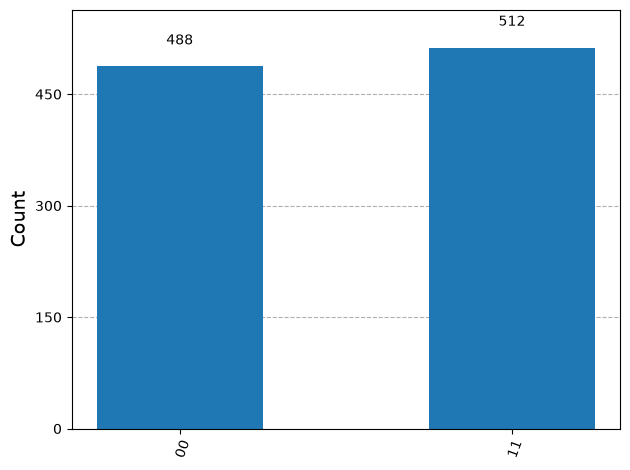

In [36]:
# Plot histogram using a Quantum Simulator
backend = AerSimulator()
counts = run_circuit_and_get_counts(phi_plus, backend, shots=1000)

plot_histogram(counts)

## Section 8: Bell - phi_minus State Construction

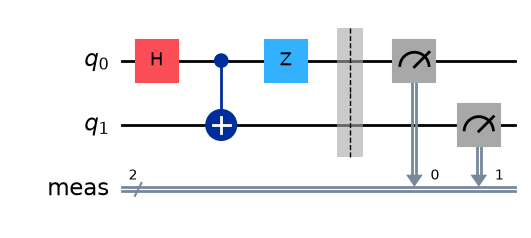

In [37]:
# ---------------------------------------------------------------------------
# Bell State Φ− (Phi Minus)
#
# |Φ−⟩ = (|00⟩ − |11⟩)/√2
# ---------------------------------------------------------------------------

# --- Build the Bell circuit (phi-minus) ---
phi_minus = QuantumCircuit(2)
phi_minus.h(0)
phi_minus.cx(0, 1)
phi_minus.z(0)
phi_minus.measure_all()  # creates a classical register named "meas"

phi_minus.draw("mpl")

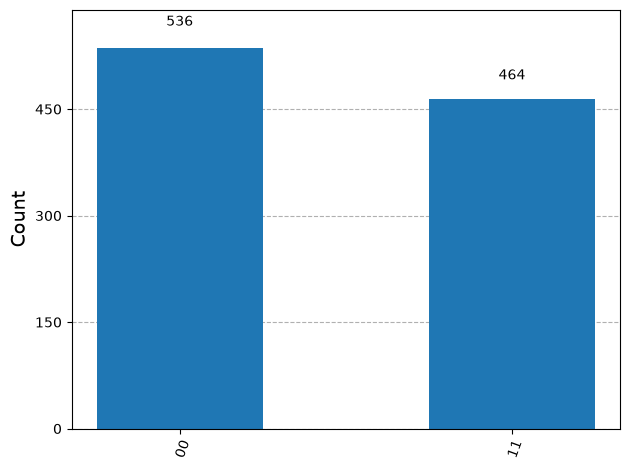

In [38]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(phi_minus, backend, shots=1000)

plot_histogram(counts)

## Section 9: Bell - psi_plus State Construction

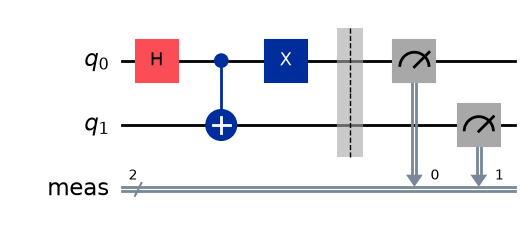

In [ ]:
# --- Build the Bell circuit (psi-plus) ---
psi_plus = QuantumCircuit(2)
psi_plus.h(0)
psi_plus.cx(0, 1)
psi_plus.x(0)
psi_plus.measure_all()  # creates a classical register named "meas"

psi_plus.draw("mpl")

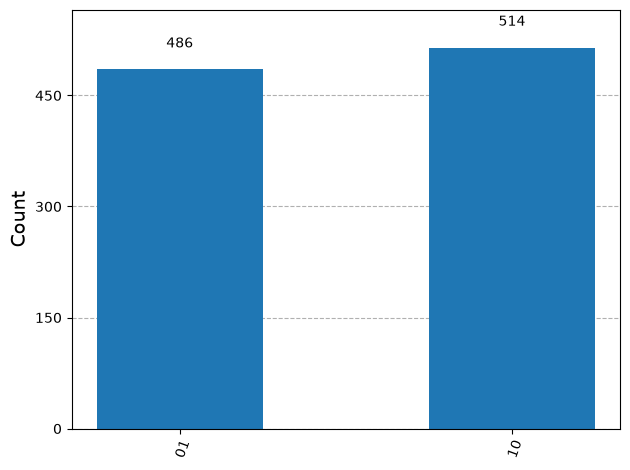

In [40]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(psi_plus, backend, shots=1000)

plot_histogram(counts)

## Section 10: Bell - psi_minus State Construction

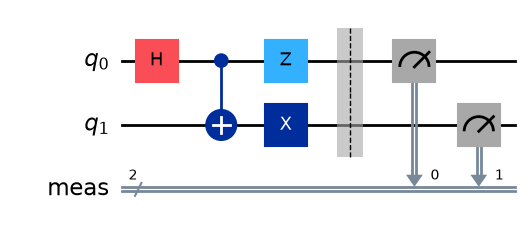

In [ ]:
# --- Build the Bell circuit (psi-minus) ---
psi_minus = QuantumCircuit(2)
psi_minus.h(0)
psi_minus.cx(0, 1)
psi_minus.z(0)
psi_minus.x(1)
psi_minus.measure_all()  # creates a classical register named "meas"

psi_minus.draw("mpl")

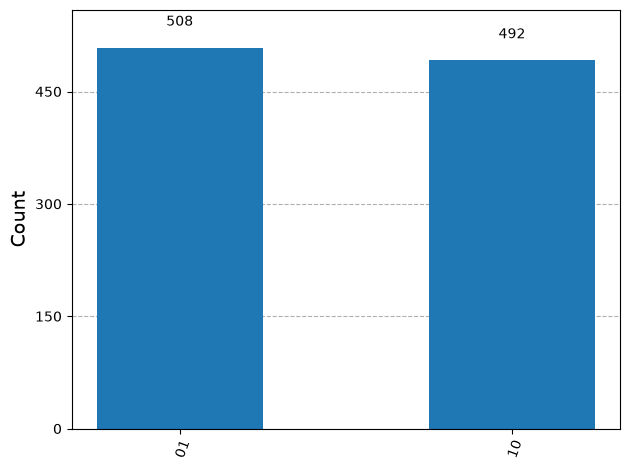

In [42]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(psi_minus, backend, shots=1000)

plot_histogram(counts)

In [43]:
# =============================================================================
# End of Project
#
# Bell States using Qiskit
# Author: Fahim Faisal
# =============================================================================